In [13]:
import os
import mne
import numpy as np
from mne.decoding import CSP
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

mne.set_log_level('WARNING')

In [14]:
def subject_hand_classifier(subjects, tmin=0, tmax=2, n_csp=2, test_size=0.3, random_state=42):
    hand_runs = ['R03', 'R04', 'R07', 'R08', 'R11', 'R12']  # strictly hand runs
    event_id = {'T1': 1, 'T2': 2}  # T1=left hand, T2=right hand
    results = {}
    
    for subj in subjects:
        print(f"\nProcessing {subj}...")
        subj_files = [f"{subj}/{f}" for f in os.listdir(subj) 
                      if f.endswith('.edf') and any(run in f for run in hand_runs)]
        
        X_subj, y_subj = [], []
        for fpath in subj_files:
            raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
            events, _ = mne.events_from_annotations(raw)
            # Only keep T1 and T2 events
            mask = np.isin(events[:, -1], [1, 2])
            if not mask.any():
                continue
            epochs = mne.Epochs(raw, events[mask], event_id=event_id,
                                tmin=tmin, tmax=tmax, baseline=None,
                                preload=True, verbose=False)
            X_subj.append(epochs.get_data())
            y_subj.append(epochs.events[:, -1] - 1)  # map 1→0 (left), 2→1 (right)
        
        if not X_subj:
            print(f"No valid hand runs for {subj}, skipping.")
            continue
        
        X_subj = np.concatenate(X_subj, axis=0)
        y_subj = np.concatenate(y_subj, axis=0)
        
        csp = CSP(n_components=n_csp, reg=None, log=True, norm_trace=False)
        X_csp = csp.fit_transform(X_subj, y_subj)
        X_scaled = StandardScaler().fit_transform(X_csp)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_subj, test_size=test_size,
            random_state=random_state, stratify=y_subj
        )
        
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        print(f"{subj} Hand Test Accuracy: {acc:.3f}")
        print(f"{subj} Hand Confusion Matrix:\n{cm}")
        results[subj] = {"accuracy": acc, "confusion_matrix": cm}
    
    return results

def subject_both_classifier(subjects, tmin=0, tmax=2, n_csp=2, test_size=0.3, random_state=42):
    foot_runs = ['R05', 'R06', 'R09', 'R10', 'R13', 'R14']  # strictly foot runs
    event_id = {'T1': 1, 'T2': 2}  # T1=both fists, T2=both feet
    results = {}
    
    for subj in subjects:
        print(f"\nProcessing {subj}...")
        subj_files = [f"{subj}/{f}" for f in os.listdir(subj) 
                      if f.endswith('.edf') and any(run in f for run in foot_runs)]
        
        X_subj, y_subj = [], []
        for fpath in subj_files:
            raw = mne.io.read_raw_edf(fpath, preload=True, verbose=False)
            events, _ = mne.events_from_annotations(raw, event_id=event_id)
            # Only keep T1 and T2 events
            mask = np.isin(events[:, -1], [1, 2])
            if not mask.any():
                continue
            epochs = mne.Epochs(raw, events[mask], event_id=event_id,
                                tmin=tmin, tmax=tmax, baseline=None,
                                preload=True, verbose=False)
            X_subj.append(epochs.get_data())
            y_subj.append(epochs.events[:, -1] - 1)  # map 1→0 (fists), 2→1 (feet)
        
        if not X_subj:
            print(f"No valid foot runs for {subj}, skipping.")
            continue
        
        X_subj = np.concatenate(X_subj, axis=0)
        y_subj = np.concatenate(y_subj, axis=0)
        
        csp = CSP(n_components=n_csp, reg=None, log=True, norm_trace=False)
        X_csp = csp.fit_transform(X_subj, y_subj)
        X_scaled = StandardScaler().fit_transform(X_csp)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y_subj, test_size=test_size,
            random_state=random_state, stratify=y_subj
        )
        
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        print(f"{subj} Foot Test Accuracy: {acc:.3f}")
        print(f"{subj} Foot Confusion Matrix:\n{cm}")
        results[subj] = {"accuracy": acc, "confusion_matrix": cm}
    
    return results

In [15]:
hand_test_results = subject_hand_classifier(['S001'])
both_test_results = subject_both_classifier(['S001'])


Processing S001...
S001 Hand Test Accuracy: 0.878
S001 Hand Confusion Matrix:
[[25  2]
 [ 3 11]]

Processing S001...
S001 Foot Test Accuracy: 0.926
S001 Foot Confusion Matrix:
[[13  0]
 [ 2 12]]


In [16]:
subjects = ['S010','S011','S012']

hand_results = subject_hand_classifier(subjects)
both_results = subject_both_classifier(subjects)


Processing S010...
S010 Hand Test Accuracy: 0.905
S010 Hand Confusion Matrix:
[[26  1]
 [ 3 12]]

Processing S011...
S011 Hand Test Accuracy: 0.805
S011 Hand Confusion Matrix:
[[22  5]
 [ 3 11]]

Processing S012...
S012 Hand Test Accuracy: 0.927
S012 Hand Confusion Matrix:
[[26  1]
 [ 2 12]]

Processing S010...
S010 Foot Test Accuracy: 0.963
S010 Foot Confusion Matrix:
[[13  1]
 [ 0 13]]

Processing S011...
S011 Foot Test Accuracy: 0.852
S011 Foot Confusion Matrix:
[[11  2]
 [ 2 12]]

Processing S012...
S012 Foot Test Accuracy: 0.815
S012 Foot Confusion Matrix:
[[11  3]
 [ 2 11]]


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrices(results, title, class_labels):
    n = len(results)

    fig, axes = plt.subplots(1, n, figsize=(4*n,4))

    if n == 1:
        axes = [axes]

    for ax, (subj, res) in zip(axes, results.items()):
        cm = res["confusion_matrix"]
        acc = res["accuracy"]

        im = ax.imshow(cm)

        ax.set_title(f"{subj}\nAccuracy = {acc:.3f}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

        ax.set_xticks([0,1])
        ax.set_yticks([0,1])
        ax.set_xticklabels(class_labels)
        ax.set_yticklabels(class_labels)

        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=14)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

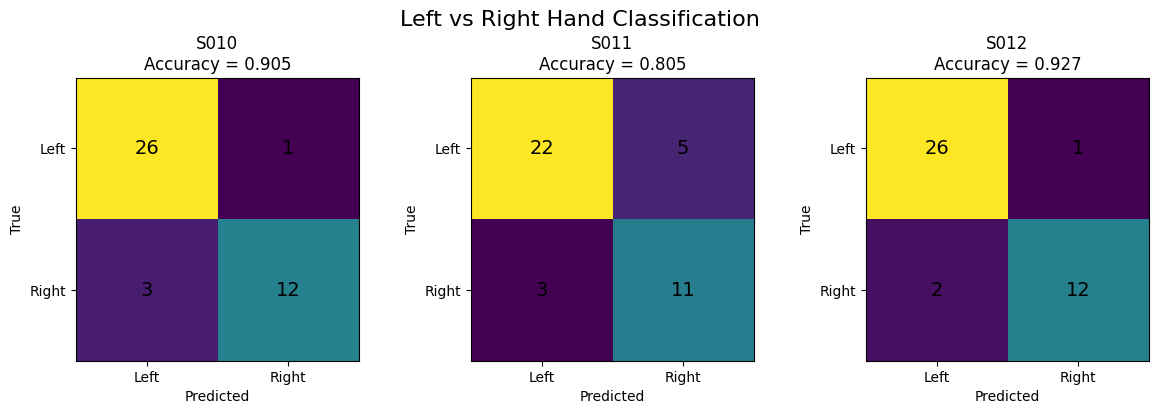

In [18]:
plot_confusion_matrices(
    hand_results,
    "Left vs Right Hand Classification",
    ["Left","Right"]
)

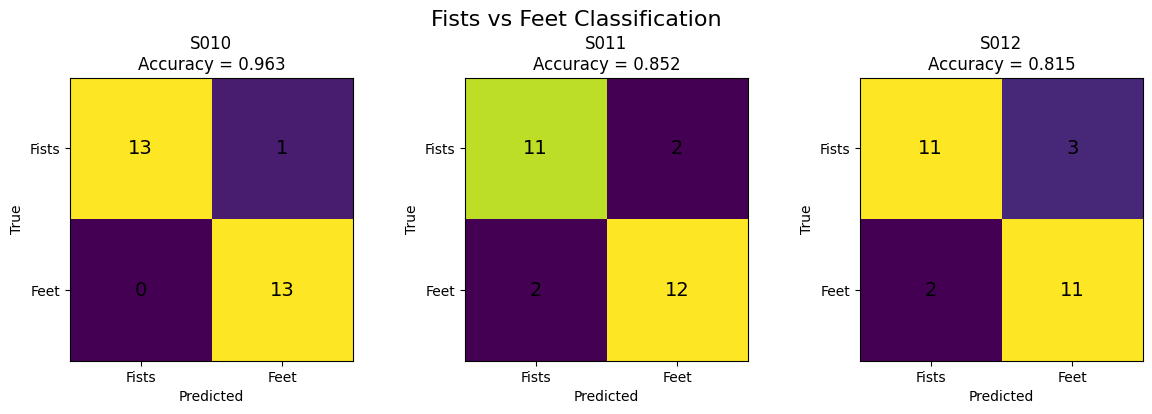

In [19]:
plot_confusion_matrices(
    both_results,
    "Fists vs Feet Classification",
    ["Fists","Feet"]
)